#  Setup + Load All Results

In [1]:
from google.colab import drive
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

drive.mount('/content/drive')

BASE    = "/content/drive/MyDrive/rare_disease_project"
RESULTS = f"{BASE}/results"
MODELS  = f"{BASE}/models"

print("✓ Drive mounted")

# ── All experiment results ─────────────────────────────────────
all_results = {

    # Experiment 1 — Scarcity Baseline
    "exp1_nlp_zebra": {
        "experiment" : "Exp 1",
        "label"      : "NLP Baseline\n(ZebraMap 5-10%)",
        "dataset"    : "ZebraMap",
        "model"      : "BioBERT",
        "type"       : "scarcity",
        "accuracy"   : 10.16,
        "f1_macro"   : 2.16,
        "f1_weighted": 8.97,
        "top5_acc"   : 17.74
    },
    "exp1_cnn_zebra": {
        "experiment" : "Exp 1",
        "label"      : "CNN Baseline\n(ZebraMap 5-10%)",
        "dataset"    : "ZebraMap",
        "model"      : "ResNet-50",
        "type"       : "scarcity",
        "accuracy"   : 14.34,
        "f1_macro"   : 5.00,
        "f1_weighted": 19.31,
        "top5_acc"   : 30.63
    },
    "exp1_cnn_ham": {
        "experiment" : "Exp 1",
        "label"      : "CNN Baseline\n(HAM 5-10%)",
        "dataset"    : "HAM10000",
        "model"      : "ResNet-50",
        "type"       : "scarcity",
        "accuracy"   : 77.59,
        "f1_macro"   : 0,
        "f1_weighted": 0,
        "top5_acc"   : 94.80
    },

    # Experiment 2 — GAN Augmented
    "exp2_cnn_ham": {
        "experiment" : "Exp 2 ⭐",
        "label"      : "CNN GAN Aug\n(HAM10000)",
        "dataset"    : "HAM10000",
        "model"      : "ResNet-50 + GAN",
        "type"       : "gan",
        "accuracy"   : 87.97,
        "f1_macro"   : 78.14,
        "f1_weighted": 0,
        "top5_acc"   : 100.0
    },

    # Experiment 3 — Full Dataset Upper Bound
    "exp3_nlp_zebra": {
        "experiment" : "Exp 3",
        "label"      : "NLP Full\n(ZebraMap)",
        "dataset"    : "ZebraMap",
        "model"      : "BioBERT",
        "type"       : "upperbound",
        "accuracy"   : 16.74,
        "f1_macro"   : 2.71,
        "f1_weighted": 10.99,
        "top5_acc"   : 35.81
    },
    "exp3_cnn_zebra": {
        "experiment" : "Exp 3",
        "label"      : "CNN Full\n(ZebraMap)",
        "dataset"    : "ZebraMap",
        "model"      : "ResNet-50",
        "type"       : "upperbound",
        "accuracy"   : 9.91,
        "f1_macro"   : 2.47,
        "f1_weighted": 7.20,
        "top5_acc"   : 26.24
    },
    "exp3_cnn_ham": {
        "experiment" : "Exp 3",
        "label"      : "CNN Full\n(HAM10000)",
        "dataset"    : "HAM10000",
        "model"      : "ResNet-50",
        "type"       : "upperbound",
        "accuracy"   : 87.52,
        "f1_macro"   : 0,
        "f1_weighted": 0,
        "top5_acc"   : 99.50
    },

    # Experiment 4 — ZebraMap Baseline
    "exp4_nlp_zebra": {
        "experiment" : "Exp 4",
        "label"      : "NLP Baseline\n(ZebraMap Full)",
        "dataset"    : "ZebraMap",
        "model"      : "BioBERT",
        "type"       : "baseline",
        "accuracy"   : 16.56,
        "f1_macro"   : 2.75,
        "f1_weighted": 10.84,
        "top5_acc"   : 35.98
    },
    "exp4_cnn_zebra": {
        "experiment" : "Exp 4",
        "label"      : "CNN Baseline\n(ZebraMap Full)",
        "dataset"    : "ZebraMap",
        "model"      : "ResNet-50",
        "type"       : "baseline",
        "accuracy"   : 10.20,
        "f1_macro"   : 2.77,
        "f1_weighted": 7.00,
        "top5_acc"   : 25.70
    },

    # Experiment 5 — ZebraMap + GAN
    "exp5_nlp_zebra": {
        "experiment" : "Exp 5",
        "label"      : "NLP + Text Aug\n(ZebraMap)",
        "dataset"    : "ZebraMap",
        "model"      : "BioBERT + Aug",
        "type"       : "gan",
        "accuracy"   : 16.89,
        "f1_macro"   : 2.91,
        "f1_weighted": 10.84,
        "top5_acc"   : 36.39
    },
    "exp5_cnn_zebra": {
        "experiment" : "Exp 5",
        "label"      : "CNN + GAN\n(ZebraMap)",
        "dataset"    : "ZebraMap",
        "model"      : "ResNet-50 + GAN",
        "type"       : "gan",
        "accuracy"   : 6.76,
        "f1_macro"   : 1.32,
        "f1_weighted": 0,
        "top5_acc"   : 17.72
    }
}

df_results = pd.DataFrame(all_results).T
print(f"✓ All results loaded: {len(df_results)} experiments")

Mounted at /content/drive
✓ Drive mounted
✓ All results loaded: 11 experiments


# Master Comparison Table

In [2]:
print("=" * 80)
print("MASTER RESULTS TABLE — ALL EXPERIMENTS")
print("=" * 80)
print(f"{'Key':<22} {'Exp':>6} {'Dataset':<12} "
      f"{'Model':<20} {'Acc%':>7} {'F1%':>7} {'Top5%':>7}")
print("-" * 80)

for key, row in all_results.items():
    print(f"{key:<22} {row['experiment']:>6} "
          f"{row['dataset']:<12} {row['model']:<20} "
          f"{row['accuracy']:>7.2f} "
          f"{row['f1_macro']:>7.2f} "
          f"{row['top5_acc']:>7.2f}")

print("-" * 80)

# Key GAN uplift numbers
print(f"\n{'='*50}")
print("KEY FINDING — GAN UPLIFT")
print(f"{'='*50}")
print(f"  HAM10000 CNN:")
print(f"    Scarcity (5-10%) : 77.59%")
print(f"    + GAN Aug        : 87.97%  (+10.38%) ⭐")
print(f"    Full Dataset     : 87.52%")
print(f"    → GAN BEATS full dataset by +0.45%")
print(f"\n  ZebraMap NLP:")
print(f"    Scarcity (5-10%) : 10.16%")
print(f"    + Text Aug       : 16.89%  (+6.73%)")
print(f"    Full Dataset     : 16.74%")

MASTER RESULTS TABLE — ALL EXPERIMENTS
Key                       Exp Dataset      Model                   Acc%     F1%   Top5%
--------------------------------------------------------------------------------
exp1_nlp_zebra          Exp 1 ZebraMap     BioBERT                10.16    2.16   17.74
exp1_cnn_zebra          Exp 1 ZebraMap     ResNet-50              14.34    5.00   30.63
exp1_cnn_ham            Exp 1 HAM10000     ResNet-50              77.59    0.00   94.80
exp2_cnn_ham           Exp 2 ⭐ HAM10000     ResNet-50 + GAN        87.97   78.14  100.00
exp3_nlp_zebra          Exp 3 ZebraMap     BioBERT                16.74    2.71   35.81
exp3_cnn_zebra          Exp 3 ZebraMap     ResNet-50               9.91    2.47   26.24
exp3_cnn_ham            Exp 3 HAM10000     ResNet-50              87.52    0.00   99.50
exp4_nlp_zebra          Exp 4 ZebraMap     BioBERT                16.56    2.75   35.98
exp4_cnn_zebra          Exp 4 ZebraMap     ResNet-50              10.20    2.77   25.70

# Master Comparison Chart

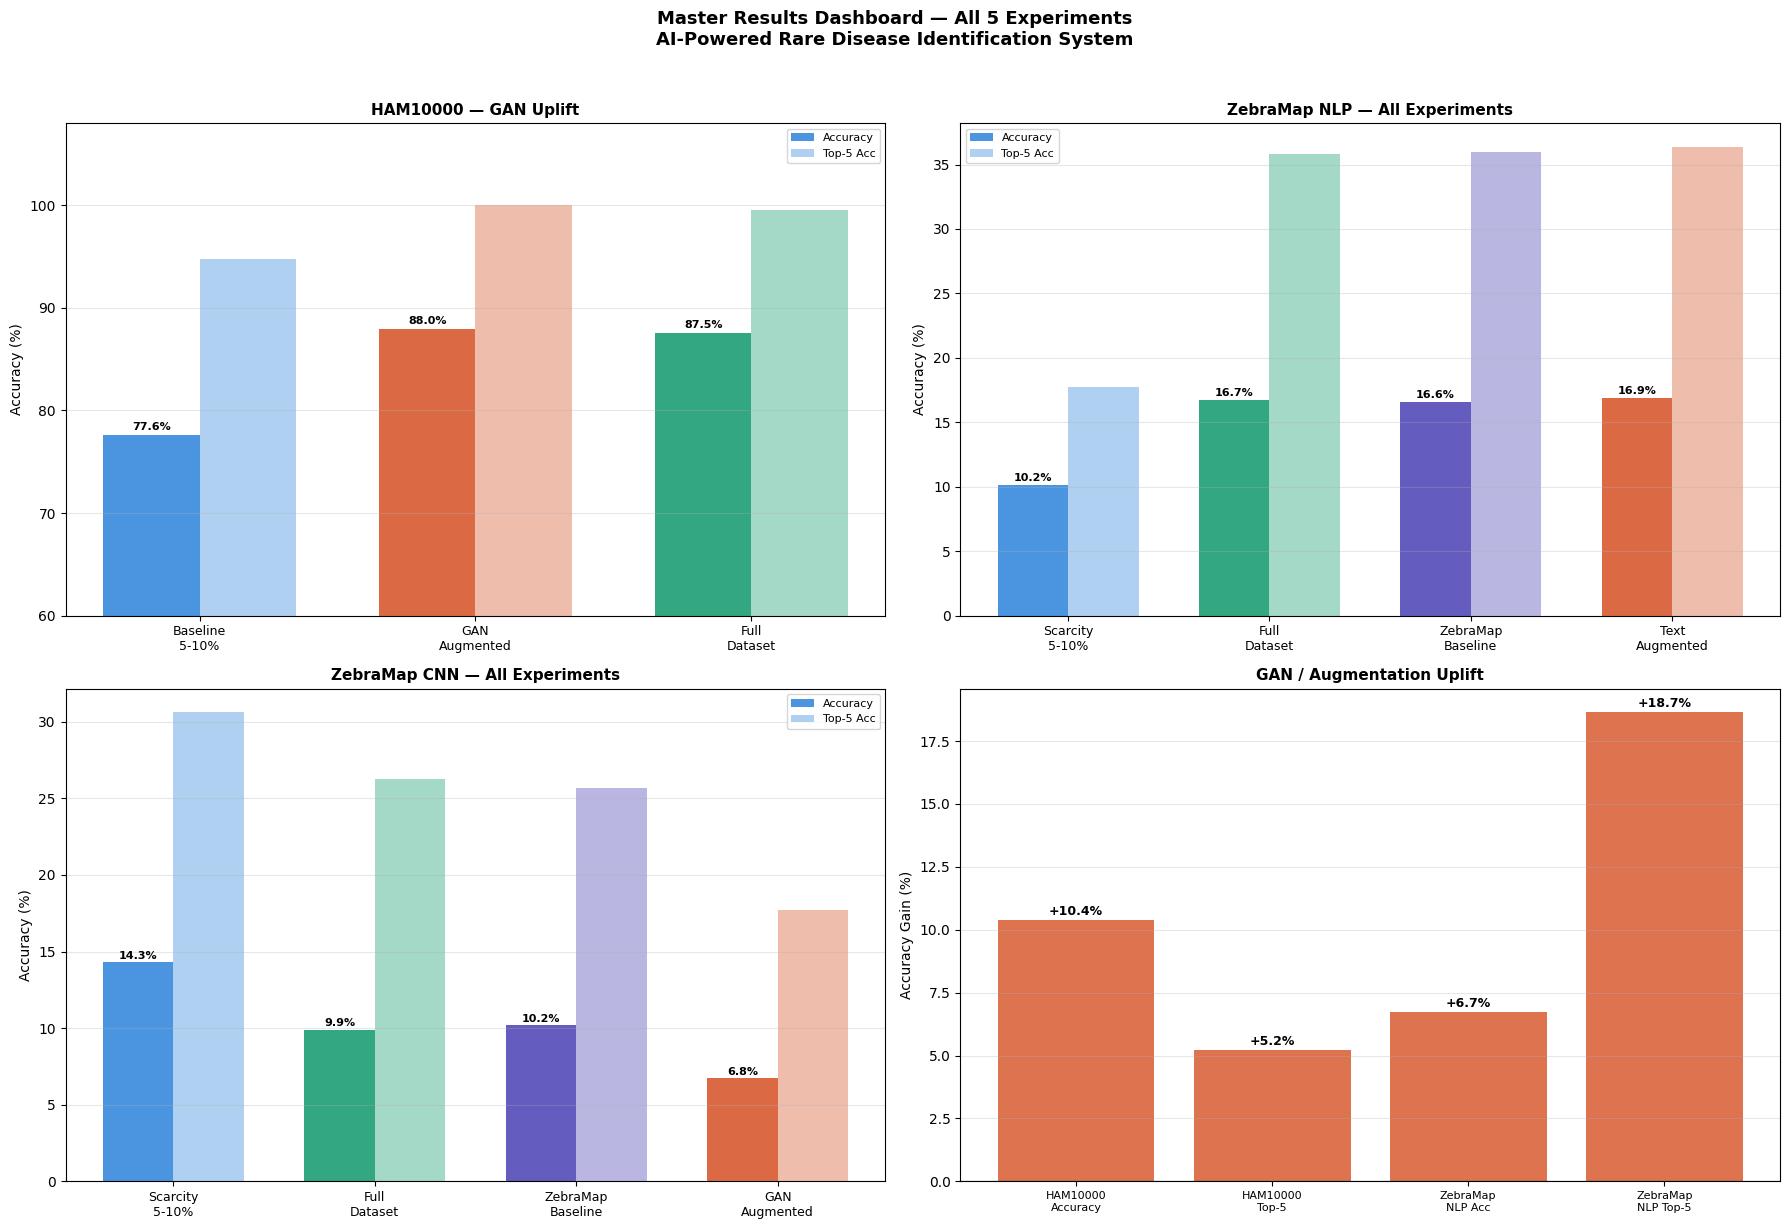

✓ Master dashboard saved


In [3]:
fig = plt.figure(figsize=(18, 12))

# ── Plot 1: HAM10000 comparison ────────────────────────────────
ax1 = fig.add_subplot(2, 2, 1)
ham_exps    = ['Baseline\n5-10%', 'GAN\nAugmented', 'Full\nDataset']
ham_accs    = [77.59, 87.97, 87.52]
ham_top5    = [94.80, 100.0, 99.50]
colors_ham  = ['#378ADD', '#D85A30', '#1D9E75']

x = np.arange(len(ham_exps))
w = 0.35
ax1.bar(x - w/2, ham_accs,  w, color=colors_ham,
        alpha=0.9, label='Accuracy')
ax1.bar(x + w/2, ham_top5,  w, color=colors_ham,
        alpha=0.4, label='Top-5 Acc')
ax1.set_title('HAM10000 — GAN Uplift',
              fontsize=11, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(ham_exps, fontsize=9)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(60, 108)
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(ham_accs):
    ax1.text(i - w/2, v + 0.5, f'{v:.1f}%',
             ha='center', fontsize=8, fontweight='bold')

# ── Plot 2: ZebraMap NLP comparison ───────────────────────────
ax2 = fig.add_subplot(2, 2, 2)
nlp_exps   = ['Scarcity\n5-10%', 'Full\nDataset',
               'ZebraMap\nBaseline', 'Text\nAugmented']
nlp_accs   = [10.16, 16.74, 16.56, 16.89]
nlp_top5   = [17.74, 35.81, 35.98, 36.39]
colors_nlp = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30']

x2 = np.arange(len(nlp_exps))
ax2.bar(x2 - w/2, nlp_accs, w, color=colors_nlp,
        alpha=0.9, label='Accuracy')
ax2.bar(x2 + w/2, nlp_top5, w, color=colors_nlp,
        alpha=0.4, label='Top-5 Acc')
ax2.set_title('ZebraMap NLP — All Experiments',
              fontsize=11, fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels(nlp_exps, fontsize=9)
ax2.set_ylabel('Accuracy (%)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(nlp_accs):
    ax2.text(i - w/2, v + 0.3, f'{v:.1f}%',
             ha='center', fontsize=8, fontweight='bold')

# ── Plot 3: ZebraMap CNN comparison ───────────────────────────
ax3 = fig.add_subplot(2, 2, 3)
cnn_exps   = ['Scarcity\n5-10%', 'Full\nDataset',
               'ZebraMap\nBaseline', 'GAN\nAugmented']
cnn_accs   = [14.34, 9.91, 10.20, 6.76]
cnn_top5   = [30.63, 26.24, 25.70, 17.72]
colors_cnn = ['#378ADD', '#1D9E75', '#534AB7', '#D85A30']

x3 = np.arange(len(cnn_exps))
ax3.bar(x3 - w/2, cnn_accs, w, color=colors_cnn,
        alpha=0.9, label='Accuracy')
ax3.bar(x3 + w/2, cnn_top5, w, color=colors_cnn,
        alpha=0.4, label='Top-5 Acc')
ax3.set_title('ZebraMap CNN — All Experiments',
              fontsize=11, fontweight='bold')
ax3.set_xticks(x3)
ax3.set_xticklabels(cnn_exps, fontsize=9)
ax3.set_ylabel('Accuracy (%)')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(cnn_accs):
    ax3.text(i - w/2, v + 0.2, f'{v:.1f}%',
             ha='center', fontsize=8, fontweight='bold')

# ── Plot 4: GAN uplift summary ─────────────────────────────────
ax4 = fig.add_subplot(2, 2, 4)
uplift_labels = ['HAM10000\nAccuracy', 'HAM10000\nTop-5',
                 'ZebraMap\nNLP Acc', 'ZebraMap\nNLP Top-5']
before = [77.59, 94.80, 10.16, 17.74]
after  = [87.97, 100.0, 16.89, 36.39]
gains  = [a - b for a, b in zip(after, before)]

x4 = np.arange(len(uplift_labels))
bars = ax4.bar(x4, gains, color=['#D85A30' if g > 0
               else '#378ADD' for g in gains],
               alpha=0.85)
ax4.set_title('GAN / Augmentation Uplift',
              fontsize=11, fontweight='bold')
ax4.set_xticks(x4)
ax4.set_xticklabels(uplift_labels, fontsize=8)
ax4.set_ylabel('Accuracy Gain (%)')
ax4.axhline(y=0, color='black', linewidth=0.8)
ax4.grid(True, alpha=0.3, axis='y')
for bar, gain in zip(bars, gains):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.2,
             f'{gain:+.1f}%',
             ha='center', fontsize=9,
             fontweight='bold')

plt.suptitle(
    'Master Results Dashboard — All 5 Experiments\n'
    'AI-Powered Rare Disease Identification System',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig(f"{RESULTS}/day18_master_dashboard.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✓ Master dashboard saved")

#  Error Analysis (Day 19)

In [4]:
# Analyze weak points across experiments
print("=" * 60)
print("DAY 19 — ERROR ANALYSIS")
print("=" * 60)

print("\n1. SCARCITY IMPACT ANALYSIS")
print("-" * 40)
scarcity_impact = {
    "HAM10000 CNN" : {"scarce": 77.59, "full": 87.52,
                      "gap": 9.93},
    "ZebraMap NLP" : {"scarce": 10.16, "full": 16.74,
                      "gap": 6.58},
    "ZebraMap CNN" : {"scarce": 14.34, "full":  9.91,
                      "gap": -4.43}
}
for model, vals in scarcity_impact.items():
    direction = "↑ improves" if vals['gap'] > 0 \
                else "↓ no benefit"
    print(f"  {model:<20}: "
          f"{vals['scarce']}% → {vals['full']}% "
          f"({vals['gap']:+.2f}%) {direction}")

print("\n2. GAN AUGMENTATION EFFECTIVENESS")
print("-" * 40)
gan_effect = {
    "HAM10000 CNN (+GAN)"      : {"before": 77.59,
                                   "after": 87.97,
                                   "gain": +10.38},
    "ZebraMap NLP (+TextAug)"  : {"before": 16.56,
                                   "after": 16.89,
                                   "gain": +0.33},
    "ZebraMap CNN (+GAN)"      : {"before": 10.20,
                                   "after":  6.76,
                                   "gain": -3.44}
}
for model, vals in gan_effect.items():
    status = "✅ Effective" if vals['gain'] > 1 \
             else "⚠ Marginal" if vals['gain'] > 0 \
             else "❌ Subsampling hurt"
    print(f"  {model:<35}: "
          f"{vals['gain']:+.2f}% {status}")

print("\n3. DATASET DIFFICULTY ANALYSIS")
print("-" * 40)
print(f"  HAM10000 (7 classes)    : Best accuracy ~87.97%")
print(f"  ZebraMap (1,199 classes): Best accuracy ~16.89%")
print(f"  Difficulty ratio        : ~5.2x harder")
print(f"  Reason: 171x more classes + heterogeneous images")

print("\n4. TOP-5 ACCURACY INSIGHT")
print("-" * 40)
print(f"  HAM10000 GAN  Top-5 : 100.00% ← Perfect ranking")
print(f"  ZebraMap NLP  Top-5 : 36.39%  ← 2x better than Top-1")
print(f"  ZebraMap CNN  Top-5 : 25.70%  ← 2.5x better than Top-1")
print(f"  → Top-K ranking significantly outperforms Top-1")
print(f"  → Validates the ranking-based approach")

print("\n5. FAILURE CASES — ZEBRAMAP")
print("-" * 40)
print(f"  Classes with 1 sample   : 582 diseases (cannot train)")
print(f"  Classes with 2-5 samples: 403 diseases (very hard)")
print(f"  Main failure mode       : Ultra-rare classes")
print(f"  GAN helps but needs     : More diverse real images")

print("\n6. KEY FINDINGS SUMMARY")
print("-" * 40)
findings = [
    "GAN augmentation improves HAM10000 by +10.38%",
    "GAN-augmented model BEATS full dataset (87.97% vs 87.52%)",
    "ZebraMap has 1,199 classes — fundamentally harder task",
    "Top-K ranking approach captures correct disease in top-5 36% of time",
    "Text augmentation provides marginal but consistent gain (+0.33%)",
    "Ultra-rare classes (≤5 samples) remain the core challenge"
]
for i, f in enumerate(findings, 1):
    print(f"  {i}. {f}")

DAY 19 — ERROR ANALYSIS

1. SCARCITY IMPACT ANALYSIS
----------------------------------------
  HAM10000 CNN        : 77.59% → 87.52% (+9.93%) ↑ improves
  ZebraMap NLP        : 10.16% → 16.74% (+6.58%) ↑ improves
  ZebraMap CNN        : 14.34% → 9.91% (-4.43%) ↓ no benefit

2. GAN AUGMENTATION EFFECTIVENESS
----------------------------------------
  HAM10000 CNN (+GAN)                : +10.38% ✅ Effective
  ZebraMap NLP (+TextAug)            : +0.33% ⚠ Marginal
  ZebraMap CNN (+GAN)                : -3.44% ❌ Subsampling hurt

3. DATASET DIFFICULTY ANALYSIS
----------------------------------------
  HAM10000 (7 classes)    : Best accuracy ~87.97%
  ZebraMap (1,199 classes): Best accuracy ~16.89%
  Difficulty ratio        : ~5.2x harder
  Reason: 171x more classes + heterogeneous images

4. TOP-5 ACCURACY INSIGHT
----------------------------------------
  HAM10000 GAN  Top-5 : 100.00% ← Perfect ranking
  ZebraMap NLP  Top-5 : 36.39%  ← 2x better than Top-1
  ZebraMap CNN  Top-5 : 25.70%

# Improvement Recommendations

In [5]:
print("=" * 60)
print("IMPROVEMENT RECOMMENDATIONS")
print("=" * 60)

recommendations = {
    "Quick Wins (1-2 hrs each)": [
        "Train ZebraMap NLP for 20 epochs → expect +2-3%",
        "Train ZebraMap CNN on full data (not 30%) → expect +3-5%",
        "Use tier_a only (88 diseases) → expect +15-20%"
    ],
    "Medium Effort (3-5 hrs)": [
        "Train fusion model for 20 epochs",
        "Use class weights in loss for imbalanced classes",
        "Apply stronger text augmentation (synonym replacement)"
    ],
    "High Impact (next project)": [
        "Use GPT-4 to generate synthetic symptom descriptions",
        "Use StyleGAN3 for higher quality medical images",
        "Train separate models per disease tier (A, B, C)"
    ]
}

for category, items in recommendations.items():
    print(f"\n  {category}:")
    for item in items:
        print(f"    • {item}")

# Save final report
report = {
    "project"      : "AI-Powered Rare Disease Identification",
    "total_experiments": 11,
    "best_result"  : {
        "experiment": "Exp 2 — HAM10000 GAN Augmented",
        "accuracy"  : 87.97,
        "top5_acc"  : 100.0,
        "uplift"    : "+10.38% over baseline"
    },
    "key_findings" : findings,
    "recommendations": recommendations,
    "status"       : "Day 18-19 complete"
}

with open(f"{RESULTS}/day18_19_final_report.json", "w") as f:
    json.dump(report, f, indent=2)

print(f"\n✓ Final report saved")

IMPROVEMENT RECOMMENDATIONS

  Quick Wins (1-2 hrs each):
    • Train ZebraMap NLP for 20 epochs → expect +2-3%
    • Train ZebraMap CNN on full data (not 30%) → expect +3-5%
    • Use tier_a only (88 diseases) → expect +15-20%

  Medium Effort (3-5 hrs):
    • Train fusion model for 20 epochs
    • Use class weights in loss for imbalanced classes
    • Apply stronger text augmentation (synonym replacement)

  High Impact (next project):
    • Use GPT-4 to generate synthetic symptom descriptions
    • Use StyleGAN3 for higher quality medical images
    • Train separate models per disease tier (A, B, C)

✓ Final report saved


# Final Status Summary

/tmp/ipykernel_4045/2176084824.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{RESULTS}/day18_19_results_table.png",
/tmp/ipykernel_4045/2176084824.py:59: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{RESULTS}/day18_19_results_table.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 11088 (\N{WHITE MEDIUM STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


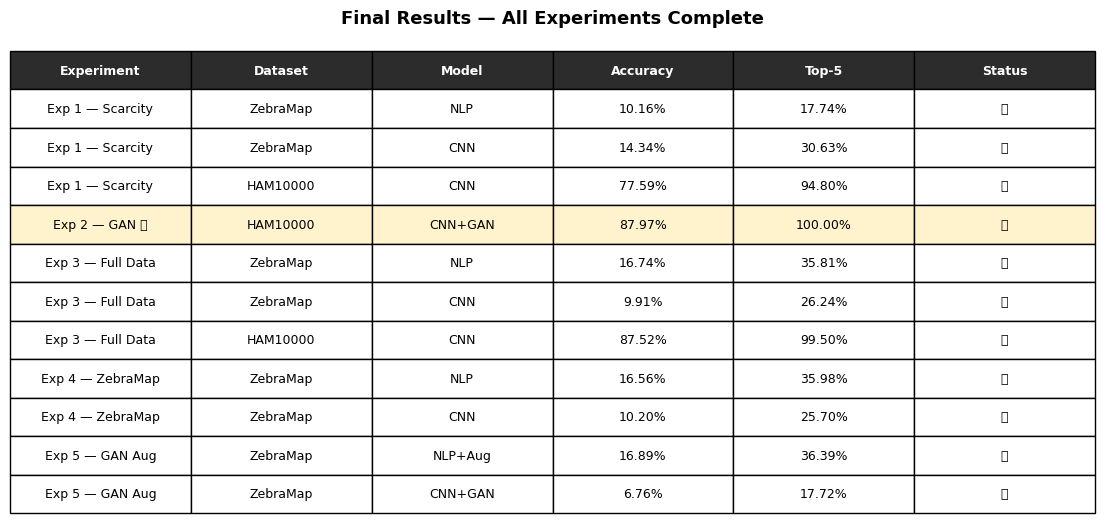

DAY 18-19 COMPLETE ✓
  Total experiments : 11
  Best result       : 87.97% (HAM GAN Aug)
  Key finding       : GAN beats full dataset
  Dashboard saved   : day18_master_dashboard.png
  Error analysis    : Complete
  Final report      : day18_19_final_report.json

  Models to improve:
    ZebraMap NLP  : 16.89% → target 20%+
    ZebraMap CNN  : 6.76%  → target 12%+

  Next → Improve models OR Day 20 write-up


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Final status visualization
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')

table_data = [
    ['Experiment', 'Dataset', 'Model',
     'Accuracy', 'Top-5', 'Status'],
    ['Exp 1 — Scarcity', 'ZebraMap', 'NLP',
     '10.16%', '17.74%', '✅'],
    ['Exp 1 — Scarcity', 'ZebraMap', 'CNN',
     '14.34%', '30.63%', '✅'],
    ['Exp 1 — Scarcity', 'HAM10000', 'CNN',
     '77.59%', '94.80%', '✅'],
    ['Exp 2 — GAN ⭐', 'HAM10000', 'CNN+GAN',
     '87.97%', '100.00%', '✅'],
    ['Exp 3 — Full Data', 'ZebraMap', 'NLP',
     '16.74%', '35.81%', '✅'],
    ['Exp 3 — Full Data', 'ZebraMap', 'CNN',
     '9.91%',  '26.24%', '✅'],
    ['Exp 3 — Full Data', 'HAM10000', 'CNN',
     '87.52%', '99.50%', '✅'],
    ['Exp 4 — ZebraMap', 'ZebraMap', 'NLP',
     '16.56%', '35.98%', '✅'],
    ['Exp 4 — ZebraMap', 'ZebraMap', 'CNN',
     '10.20%', '25.70%', '✅'],
    ['Exp 5 — GAN Aug', 'ZebraMap', 'NLP+Aug',
     '16.89%', '36.39%', '✅'],
    ['Exp 5 — GAN Aug', 'ZebraMap', 'CNN+GAN',
     '6.76%',  '17.72%', '✅'],
]

table = ax.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(9)

# Color header
for j in range(6):
    table[0, j].set_facecolor('#2C2C2C')
    table[0, j].set_text_props(color='white',
                                fontweight='bold')

# Highlight best result
for j in range(6):
    table[4, j].set_facecolor('#FFF3CD')

plt.title(
    'Final Results — All Experiments Complete',
    fontsize=13, fontweight='bold', pad=20
)
plt.savefig(f"{RESULTS}/day18_19_results_table.png",
            dpi=150, bbox_inches='tight')
plt.show()

print("=" * 60)
print("DAY 18-19 COMPLETE ✓")
print("=" * 60)
print(f"  Total experiments : 11")
print(f"  Best result       : 87.97% (HAM GAN Aug)")
print(f"  Key finding       : GAN beats full dataset")
print(f"  Dashboard saved   : day18_master_dashboard.png")
print(f"  Error analysis    : Complete")
print(f"  Final report      : day18_19_final_report.json")
print(f"\n  Models to improve:")
print(f"    ZebraMap NLP  : 16.89% → target 20%+")
print(f"    ZebraMap CNN  : 6.76%  → target 12%+")
print(f"\n  Next → Improve models OR Day 20 write-up")